# Text Classification Evaluation Notebook

This notebook evaluates the accuracy of text descriptions generated by Gemini models and analyzes the correlation between accuracy and preserved semantic distances across categories.

## Workflow:
1. Load data from JSON (categories and texts).
2. Split data 80% training / 20% testing.
3. Generate descriptions using Gemini 3.1 Flash lite.
4. Classify training data in randomized batches of 20.
5. Evaluate performance with charts and tables.
6. Measure semantic distance preservation.
7. Analyze correlation between accuracy and semantic distance.
8. Ablation study with Gemini 3.5 Flash.

## 1. Setup and Configuration
Install necessary libraries and configure the Gemini API.

In [9]:
!pip install -q google-genai pandas numpy matplotlib seaborn scikit-learn scipy sentence-transformers

import os
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from sentence_transformers import SentenceTransformer
from datetime import datetime

from google.colab import userdata

# Retrieve the secret from Colab's secret manager
try:
    api_key = userdata.get('GOOGLE_API_KEY')

    # Set it as an environment variable so your existing code/SDK works seamlessly
    os.environ['GOOGLE_API_KEY'] = api_key

except userdata.NotebookAccessError:
    print("Please click the key icon on the left and grant notebook access to GOOGLE_API_KEY.")
except userdata.SecretNotFoundError:
    print("The secret GOOGLE_API_KEY was not found. Please add it to the Secrets panel.")


# Configuration
CONFIG = {
    'MODEL_31': 'gemini-3.1-flash-lite',
    'MODEL_35': 'gemini-3.5-flash-latest',
    'OUTPUT_DIR': '/content/drive/MyDrive/classification_outputs',
    'REUSE_CACHE': True,
    'DISMISS_HINTS': True,
    'EMBEDDING_MODEL_NAME': 'all-MiniLM-L6-v2',
    'API_KEY': os.getenv('GOOGLE_API_KEY')
}

if not os.path.exists(CONFIG['OUTPUT_DIR']):
    try:
        os.makedirs(CONFIG['OUTPUT_DIR'])
    except OSError:
        os.makedirs('outputs', exist_ok=True)
        CONFIG['OUTPUT_DIR'] = 'outputs'

client = genai.Client(api_key=CONFIG['API_KEY'])
embedding_model = SentenceTransformer(CONFIG['EMBEDDING_MODEL_NAME'])


## 2. Data Loading
Mount Google Drive and load the dataset from the specified path.

In [4]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab or drive mount failed.')

def load_data(file_path):
    if not os.path.exists(file_path):
        print(f'Warning: File not found at {file_path}. Using dummy data.')
        return {
            'technology': ['Computers are fast', 'Software is evolving', 'AI is the future', 'Hardware improves over time'],
            'sports': ['Football is popular', 'Basketball requires skill', 'Tennis is played on grass or clay', 'Running is good exercise'],
            'cooking': ['Baking requires precision', 'Spices add flavor', 'Italian cuisine is famous', 'Vegetables are healthy']
        }
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

DATA_PATH = '/content/drive/MyDrive/Graphiko/exports/base_data/latest/channel_titles.json'
data = load_data(DATA_PATH)

Mounted at /content/drive


## 3. Data Splitting
Split data 80% training and 20% testing per category.

In [5]:
train_data = {}
test_data = {}

for category, texts in data.items():
    train, test = train_test_split(texts, test_size=0.2, random_state=42)
    train_data[category] = train
    test_data[category] = test

print(f'Categories: {list(data.keys())}')

Categories: ['20VC with Harry Stebbings', 'ARK Invest', 'Alex Hormozi', 'All-In Podcast', 'Anthony Pompliano', 'Asianometry', 'Bg2 Pod', 'Bloomberg Originals', 'Dan Martell', 'Garry Tan', 'Greg Isenberg', 'Joe Lonsdale', "Lenny's Podcast", 'My First Million', 'Network State Podcast', 'Patrick Boyle', 'Peter H. Diamandis', 'Principles by Ray Dalio', 'Real Vision Presents', 'Sequoia Capital', 'The Prof G Pod – Scott Galloway', 'This Week in Startups', 'Tim Ferriss', 'Tony Robbins', 'Valuetainment', 'Y Combinator', 'a16z']


## 4. LLM Caching Utility
Save and load LLM responses to avoid hitting quotas.

In [6]:
def get_cache_path(name, timestamp=None):
    if timestamp:
        return os.path.join(CONFIG['OUTPUT_DIR'], f'{name}_{timestamp}.json')
    return os.path.join(CONFIG['OUTPUT_DIR'], f'{name}_latest.json')

def save_cache(name, data):
    # Save latest
    latest_path = get_cache_path(name)
    with open(latest_path, 'w') as f:
        json.dump(data, f)
    
    # Save timestamped copy
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    versioned_path = get_cache_path(name, timestamp=timestamp)
    with open(versioned_path, 'w') as f:
        json.dump(data, f)

def load_cache(name):
    path = get_cache_path(name)
    if CONFIG['REUSE_CACHE'] and os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None


## 5. Classification Helper Function
A helper function to classify texts in batches using category descriptions.

In [12]:
import time

def classify_texts(texts_with_labels, descriptions, model_name, cache_name):
    results = load_cache(cache_name) or []

    # Identify which texts still need classification
    processed_texts = {r['text'] for r in results}
    to_process = [t for t in texts_with_labels if t['text'] not in processed_texts]

    if not to_process:
        print(f'All texts already classified for {cache_name}.')
        return pd.DataFrame(results)

    batch_size = 20
    for i in range(0, len(to_process), batch_size):
        batch = to_process[i:i+batch_size]

        desc_str = '\n'.join([f'{cat}: {desc}' for cat, desc in descriptions.items()])
        texts_to_classify = '\n'.join([f"[{j}] {item['text']}" for j, item in enumerate(batch)])

        prompt = f'Classify the following texts into one of these categories:\n{desc_str}\n\nTexts:\n{texts_to_classify}\n\nReturn only a JSON list of category names in order.'
        time.sleep(5)  # To avoid hitting quotas

        try:
            response = client.models.generate_content(model=model_name, contents=prompt)
            res_text = response.text.strip()
            if '```json' in res_text: res_text = res_text.split('```json')[1].split('```')[0]
            predictions = json.loads(res_text)

            for j, pred in enumerate(predictions):
                if j < len(batch):
                    batch[j]['prediction'] = pred
                    results.append(batch[j])

            # Incremental save
            save_cache(cache_name, results)
            print(f'Processed batch {i//batch_size + 1}/{(len(to_process)-1)//batch_size + 1}')
        except Exception as e:
            print(f'Error processing batch starting at {i}: {e}')

    return pd.DataFrame(results)

## 6. Iterative Description Generation
Generate descriptions for each category using Gemini 3.1 Flash lite.

In [11]:
import time

def contains_hint(category, texts):
    """Check if the category name appears in any of the example texts (case-insensitive)."""
    cat_lower = category.lower()
    for text in texts:
        if cat_lower in text.lower():
            return True
    return False

descriptions_31 = load_cache('descriptions_31') or {}
valid_categories = []
discarded_categories = []

for category, texts in train_data.items():
    if CONFIG['DISMISS_HINTS'] and contains_hint(category, texts):
        discarded_categories.append(category)
        continue
    
    valid_categories.append(category)

print(f'Discarded categories (hints found): {discarded_categories}')

for category in valid_categories:
    if category in descriptions_31:
        continue

    texts = train_data[category]
    prompt = f'Provide a concise description of the following category based on these examples: {category}\nExamples:\n' + '\n'.join(texts)
    response = client.models.generate_content(model=CONFIG['MODEL_31'], contents=prompt)
    descriptions_31[category] = response.text
    save_cache('descriptions_31', descriptions_31)
    time.sleep(5)  # To avoid hitting quotas

print('Descriptions generated for all valid categories.')


Descriptions generated for all categories.


## 7. Batch Classification
Classify training data in randomized batches of 20 using the generated descriptions.

In [13]:
all_test_texts = []
for category in valid_categories:
    texts = test_data[category]
    for t in texts:
        all_test_texts.append({'text': t, 'label': category})

random.seed(42)
random.shuffle(all_test_texts)

# Filter descriptions to only include valid categories for classification task
valid_descriptions = {cat: descriptions_31[cat] for cat in valid_categories if cat in descriptions_31}

df_results = classify_texts(all_test_texts, valid_descriptions, CONFIG['MODEL_31'], 'classification_results_31')
print('Classification complete on test split.')


Processed batch 1/54
Processed batch 2/54
Processed batch 3/54
Processed batch 4/54
Processed batch 5/54
Processed batch 6/54
Processed batch 7/54
Processed batch 8/54
Processed batch 9/54
Processed batch 10/54
Processed batch 11/54
Processed batch 12/54
Processed batch 13/54
Processed batch 14/54
Processed batch 15/54
Processed batch 16/54
Processed batch 17/54
Processed batch 18/54
Processed batch 19/54
Processed batch 20/54
Processed batch 21/54
Processed batch 22/54
Processed batch 23/54
Processed batch 24/54
Processed batch 25/54
Processed batch 26/54
Processed batch 27/54
Processed batch 28/54
Processed batch 29/54
Processed batch 30/54
Processed batch 31/54
Processed batch 32/54
Processed batch 33/54
Processed batch 34/54
Processed batch 35/54
Processed batch 36/54
Processed batch 37/54
Processed batch 38/54
Processed batch 39/54
Processed batch 40/54
Processed batch 41/54
Processed batch 42/54
Processed batch 43/54
Processed batch 44/54
Processed batch 45/54
Processed batch 46/

## 8. Performance Evaluation Helper
Helper to print metrics and show charts.

Global Accuracy (Gemini 3.1 Flash lite): 0.4863


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
20VC with Harry Stebbings,0.259259,0.358974,0.301075,39.000000
ARK Invest,0.739130,0.425000,0.539683,40.000000
Alex Hormozi,0.267606,0.487179,0.345455,39.000000
All-In Podcast,0.392857,0.282051,0.328358,39.000000
Anthony Pompliano,0.500000,0.743590,0.597938,39.000000
Asianometry,0.673913,0.775000,0.720930,40.000000
Bg2 Pod,0.555556,0.882353,0.681818,34.000000
Bloomberg Originals,0.648649,0.615385,0.631579,39.000000
Dan Martell,0.343750,0.289474,0.314286,38.000000
Garry Tan,0.142857,0.050000,0.074074,40.000000


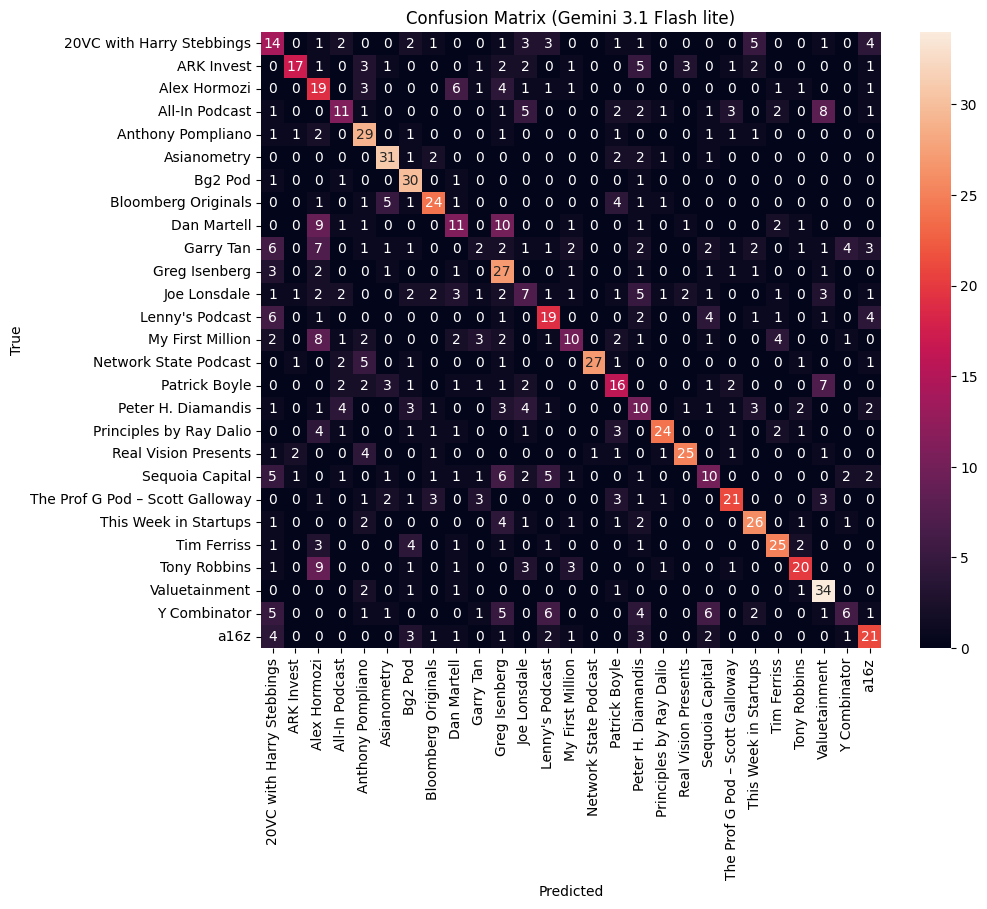

0.48633364750235625

In [14]:
def evaluate_performance(df, title_suffix=''):
    accuracy = accuracy_score(df['label'], df['prediction'])
    print(f'Global Accuracy {title_suffix}: {accuracy:.4f}')

    report = classification_report(df['label'], df['prediction'], output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    display(df_report)

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    categories = sorted(df['label'].unique())
    cm = confusion_matrix(df['label'], df['prediction'], labels=categories)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix {title_suffix}')
    plt.show()
    return accuracy

evaluate_performance(df_results, '(Gemini 3.1 Flash lite)')

## 9. Semantic Distance Preservation Metric
Evaluate how distances across categories were preserved compared to distribution of the texts.

In [16]:
embedding_cache = load_cache('embedding_cache') or {}
new_embeddings_count = 0

def get_embedding(text):
    global new_embeddings_count
    if text in embedding_cache:
        return embedding_cache[text]
    
    embedding = embedding_model.encode([text])[0].tolist()
    embedding_cache[text] = embedding
    new_embeddings_count += 1
    
    # Periodically save the cache
    if new_embeddings_count >= 50:
        save_cache('embedding_cache', embedding_cache)
        new_embeddings_count = 0
        
    return embedding

def calculate_preservation(data_split, descriptions):
    # 1. Calculate centroid embeddings for each category from raw texts
    category_centroids = {}
    # Filter data_split to only include valid_categories
    valid_data = {cat: texts for cat, texts in data_split.items() if cat in valid_categories}
    
    for category, texts in valid_data.items():
        embeddings = [get_embedding(t) for t in texts]
        category_centroids[category] = np.mean(embeddings, axis=0)

    # 2. Calculate distance matrix for categories (raw texts)
    categories = sorted(list(valid_data.keys()))
    dist_raw = np.zeros((len(categories), len(categories)))
    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            dist_raw[i, j] = cosine(category_centroids[cat1], category_centroids[cat2])

    # 3. Calculate distance matrix for category descriptions
    # Filter descriptions to only include valid_categories
    valid_desc = {cat: desc for cat, desc in descriptions.items() if cat in valid_categories}
    desc_embeddings = {cat: get_embedding(desc) for cat, desc in valid_desc.items()}
    
    dist_desc = np.zeros((len(categories), len(categories)))
    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            dist_desc[i, j] = cosine(desc_embeddings[cat1], desc_embeddings[cat2])

    # Metric: Correlation between dist_raw and dist_desc
    raw_flat = dist_raw[np.triu_indices(len(categories), k=1)]
    desc_flat = dist_desc[np.triu_indices(len(categories), k=1)]
    preservation_score, _ = pearsonr(raw_flat, desc_flat)
    
    # Final save of embedding cache
    save_cache('embedding_cache', embedding_cache)
    
    return preservation_score, dist_raw, dist_desc, categories

pres_score, dist_raw, dist_desc, categories = calculate_preservation(train_data, descriptions_31)
print(f'Semantic Distance Preservation Score: {pres_score:.4f}')


ClientError: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': '* BatchEmbedContentsRequest.model: unexpected model name format\n* BatchEmbedContentsRequest.requests[0].model: unexpected model name format\n', 'status': 'INVALID_ARGUMENT'}}

## 10. Correlation Analysis
Determine if there is a correlation between text description accuracy and preserved semantic distance.

In [ ]:
def analyze_correlation(df_results, dist_raw, dist_desc, categories):
    # Accuracy per category
    cat_accuracy = df_results.groupby('label').apply(lambda x: accuracy_score(x['label'], x['prediction']))

    # Distance preservation per category (mean correlation of its distances to others)
    cat_preservation = {}
    for i, cat in enumerate(categories):
        cat_preservation[cat] = pearsonr(dist_raw[i], dist_desc[i])[0]

    analysis_df = pd.DataFrame({
        'Accuracy': cat_accuracy,
        'Preservation': pd.Series(cat_preservation)
    })

    plt.figure(figsize=(8, 6))
    sns.regplot(data=analysis_df, x='Preservation', y='Accuracy')
    plt.title('Correlation: Description Accuracy vs Semantic Preservation')
    plt.show()

    corr_val, p_val = pearsonr(analysis_df['Preservation'], analysis_df['Accuracy'])
    print(f'Pearson Correlation: {corr_val:.4f} (p={p_val:.4f})')

    print('\nFinal Conclusion:')
    if corr_val > 0.5 and p_val < 0.05:
        print('There IS a significant positive correlation. Higher preservation of semantic distances leads to better classification accuracy.')
    else:
        print('There is NO strong evidence of correlation in this dataset. Accuracy may be driven by other factors like description clarity or category distinctness.')
    return corr_val

analyze_correlation(df_results, dist_raw, dist_desc, categories)

## 11. Ablation Study: Gemini 3.5 Flash (Single Request)
Compare results with descriptions generated by Gemini 3.5 Flash in a single request.

In [ ]:
ablation_descriptions = load_cache('ablation_descriptions')

if not ablation_descriptions:
    # Filter train_data to only include valid_categories for description generation
    valid_train_data = {cat: texts for cat, texts in train_data.items() if cat in valid_categories}
    
    # Generate ALL descriptions in a single request
    all_train_formatted = json.dumps(valid_train_data)
    prompt = f'Generate concise descriptions for ALL the following categories based on their examples:\n{all_train_formatted}\nReturn a JSON object where keys are category names and values are descriptions.'

    response = client.models.generate_content(model=CONFIG['MODEL_35'], contents=prompt)
    res_text = response.text.strip()
    if '```json' in res_text: res_text = res_text.split('```json')[1].split('```')[0]
    ablation_descriptions = json.loads(res_text)
    save_cache('ablation_descriptions', ablation_descriptions)

print('Ablation descriptions generated.')

# Run Classification for Ablation using test split and valid categories
df_results_ablation = classify_texts(all_test_texts, ablation_descriptions, CONFIG['MODEL_31'], 'classification_results_35')

# Evaluate Ablation
evaluate_performance(df_results_ablation, '(Gemini 3.5 Flash - Ablation)')

# Preservation Score for Ablation
pres_score_ab, dist_raw_ab, dist_desc_ab, cats_ab = calculate_preservation(test_data, ablation_descriptions)
print(f'Ablation Semantic Distance Preservation Score: {pres_score_ab:.4f}')

# Correlation for Ablation
analyze_correlation(df_results_ablation, dist_raw_ab, dist_desc_ab, cats_ab)
